# Memory Capacity and Spatial Navigation Efficiency

**FIXED VERSION** - Shows actual results, proper loop detection, no arbitrary timeouts

---

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from labyrinth import LabyrinthEnv
from Agent import QLearning_agent, HeuristicAgent
from memory_hierarchy_agents import ReactiveAgent, MinimalMemoryAgent, FullMemoryAgent

print('✓ Modules loaded')

✓ Modules loaded


## Helper Functions with Loop Detection

In [14]:
def detect_loop(history, window=20):
    """Detect if agent is stuck in a loop."""
    if len(history) < window:
        return False
    
    recent = history[-window:]
    
    # Check if oscillating between 2-3 states
    unique_states = len(set(recent))
    if unique_states <= 3:
        return True
    
    # Check if stuck at single state
    if unique_states == 1:
        return True
    
    return False


def run_episode(agent, env, agent_type='reactive', max_steps=10000, seed=None):
    """
    Run single episode with loop detection.
    
    Returns:
        dict with: steps, completed, stuck_in_loop, visited_nodes
    """
    obs, info = env.reset(seed=seed)
    
    if hasattr(agent, 'reset'):
        agent.reset()
    
    state_history = []
    visited_nodes = set()
    done = False
    steps = 0
    stuck = False
    
    while not done and steps < max_steps:
        current_node = info['node']
        visited_nodes.add(current_node)
        state_history.append(current_node)
        
        # Loop detection every 20 steps
        if steps > 0 and steps % 20 == 0:
            if detect_loop(state_history):
                stuck = True
                break
        
        # Choose action
        if agent_type in ['reactive', 'minimal']:
            action = agent.choose_action(obs, info['has_water'], info['at_dead_end'])
        else:  # Q-learning
            action = agent.choose_action(obs)
        
        obs, reward, done, truncated, info = env.step(action)
        steps += 1
    
    return {
        'steps': steps,
        'completed': done,
        'stuck_in_loop': stuck,
        'hit_limit': (steps >= max_steps and not done),
        'visited_nodes': len(visited_nodes),
        'coverage': len(visited_nodes) / env.num_nodes
    }


def evaluate_agent(agent, env, agent_type='reactive', num_trials=50, max_steps=10000):
    """Evaluate agent across multiple trials."""
    results = []
    
    for trial in range(num_trials):
        result = run_episode(agent, env, agent_type, max_steps, seed=3000+trial)
        results.append(result)
    
    # Aggregate
    df = pd.DataFrame(results)
    
    summary = {
        'total_trials': num_trials,
        'completed': df['completed'].sum(),
        'stuck_in_loop': df['stuck_in_loop'].sum(),
        'hit_limit': df['hit_limit'].sum(),
        'completion_rate': df['completed'].mean(),
        'avg_steps': df['steps'].mean(),
        'avg_steps_completed': df[df['completed']]['steps'].mean() if df['completed'].sum() > 0 else None,
        'avg_coverage': df['coverage'].mean(),
        'avg_nodes': df['visited_nodes'].mean()
    }
    
    return summary, df

print('✓ Helper functions defined with loop detection')

✓ Helper functions defined with loop detection


---

# PART 1: Original Approach - Single Night Analysis

## Train Cognitive Map Agent

In [15]:
env = LabyrinthEnv(k=2, depth=6)
print(f"Environment: k={env.k}, depth={env.depth}, nodes={env.num_nodes}")
print(f"Optimal path: 12 steps\n")

# Train Q-learning
print("Training Q-learning agent...")
map_agent = QLearning_agent(env.observation_space.n, env.action_space.n)

training_steps = 0
consecutive_optimal = 0

for episode in range(1000):
    obs, info = env.reset()
    done = False
    episode_steps = 0
    
    while not done and episode_steps < 10000:
        action = map_agent.choose_action(obs)
        next_obs, reward, done, truncated, info = env.step(action)
        map_agent.learn(obs, action, reward, next_obs, done)
        obs = next_obs
        episode_steps += 1
        training_steps += 1
    
    if episode_steps == 12:
        consecutive_optimal += 1
        if consecutive_optimal >= 5:
            print(f"  ✓ Converged at episode {episode+1}")
            print(f"  ✓ Total training: {training_steps:,} steps\n")
            break
    else:
        consecutive_optimal = 0

# Evaluate
print("Evaluating trained agent...")
map_agent.epsilon = 0.0
map_summary, map_df = evaluate_agent(map_agent, env, 'qlearning', num_trials=50)

print(f"  Completion rate: {map_summary['completion_rate']:.0%}")
print(f"  Avg steps: {map_summary['avg_steps']:.1f}")
print(f"  Stuck in loops: {map_summary['stuck_in_loop']}")

Environment: k=2, depth=6, nodes=127
Optimal path: 12 steps

Training Q-learning agent...
  ✓ Converged at episode 276
  ✓ Total training: 29,314 steps

Evaluating trained agent...
  Completion rate: 100%
  Avg steps: 12.0
  Stuck in loops: 0


## Test Original Heuristic Agent

In [16]:
print("Testing original heuristic agent...")
heur_agent = HeuristicAgent(k_actions=env.k)
heur_summary, heur_df = evaluate_agent(heur_agent, env, 'reactive', num_trials=50)

print(f"  Completion rate: {heur_summary['completion_rate']:.0%}")
print(f"  Avg steps: {heur_summary['avg_steps']:.1f}")
if heur_summary['avg_steps_completed']:
    print(f"  Avg steps (when completed): {heur_summary['avg_steps_completed']:.1f}")
print(f"  Stuck in loops: {heur_summary['stuck_in_loop']}")
print(f"  Hit time limit: {heur_summary['hit_limit']}")

Testing original heuristic agent...
  Completion rate: 24%
  Avg steps: 8811.0
  Avg steps (when completed): 5046.0
  Stuck in loops: 0
  Hit time limit: 38


## Single-Night Comparison (N=100)

In [17]:
N = 100

print("="*70)
print("SINGLE-NIGHT ANALYSIS (N=100 foraging cycles)")
print("="*70)

# Use actual steps per episode
map_steps_per = map_summary['avg_steps']
heur_steps_per = heur_summary['avg_steps_completed'] if heur_summary['avg_steps_completed'] else heur_summary['avg_steps']

map_total = training_steps + (N * map_steps_per)
heur_total = N * heur_steps_per

print(f"\nCognitive Map:")
print(f"  Training: {training_steps:,} steps")
print(f"  Exploitation: {N * map_steps_per:,.0f} steps ({map_steps_per:.1f} per trip)")
print(f"  Total: {map_total:,.0f} steps")
print(f"  Exploration fraction: {training_steps/map_total:.1%}")

print(f"\nHeuristic:")
print(f"  Completion rate: {heur_summary['completion_rate']:.0%}")
print(f"  Steps per trip: {heur_steps_per:.1f}")
print(f"  Total (if completes): {heur_total:,.0f} steps")

if heur_summary['completion_rate'] < 0.5:
    print(f"\n⚠️  PROBLEM: Heuristic completion rate too low ({heur_summary['completion_rate']:.0%})")
    print(f"   Pure heuristics cannot reliably complete task!")
    print(f"   → This motivates the memory hierarchy approach")
elif heur_total < map_total:
    print(f"\n  Winner: Heuristic ({(map_total-heur_total)/map_total:.1%} fewer steps)")
else:
    print(f"\n  Winner: Cognitive Map ({(heur_total-map_total)/heur_total:.1%} fewer steps)")

print(f"\nRosenberg observed: 84% exploration")
print(f"Map prediction: {training_steps/map_total:.1%}")

SINGLE-NIGHT ANALYSIS (N=100 foraging cycles)

Cognitive Map:
  Training: 29,314 steps
  Exploitation: 1,200 steps (12.0 per trip)
  Total: 30,514 steps
  Exploration fraction: 96.1%

Heuristic:
  Completion rate: 24%
  Steps per trip: 5046.0
  Total (if completes): 504,600 steps

⚠️  PROBLEM: Heuristic completion rate too low (24%)
   Pure heuristics cannot reliably complete task!
   → This motivates the memory hierarchy approach

Rosenberg observed: 84% exploration
Map prediction: 96.1%


---

# PART 2: Problem Identification

In [18]:
print("="*70)
print("WHY ORIGINAL APPROACH HAS ISSUES")
print("="*70)

if heur_summary['completion_rate'] < 0.5:
    print(f"\n⚠️  CRITICAL ISSUE: Heuristic completion = {heur_summary['completion_rate']:.0%}")
    print(f"\nWhy pure heuristics fail:")
    print(f"  • No spatial memory → cannot remember visited areas")
    print(f"  • Gets stuck in loops: {heur_summary['stuck_in_loop']}/{heur_summary['total_trials']} trials")
    print(f"  • Explores redundantly → revisits same subtrees")
    print(f"  • Only remembers 1 banned branch → insufficient for 64 endpoints")
    
    print(f"\n💡 INSIGHT: The constraint is MEMORY CAPACITY, not strategy choice")
    print(f"\n   → This motivates asking: How much memory is needed?")
else:
    print(f"\n✓ Heuristic works ({heur_summary['completion_rate']:.0%} completion)")
    print(f"  Original comparison is meaningful")

print("\n" + "="*70)

WHY ORIGINAL APPROACH HAS ISSUES

⚠️  CRITICAL ISSUE: Heuristic completion = 24%

Why pure heuristics fail:
  • No spatial memory → cannot remember visited areas
  • Gets stuck in loops: 0/50 trials
  • Explores redundantly → revisits same subtrees
  • Only remembers 1 banned branch → insufficient for 64 endpoints

💡 INSIGHT: The constraint is MEMORY CAPACITY, not strategy choice

   → This motivates asking: How much memory is needed?



---

# PART 3: Memory Hierarchy Analysis

## Level 0: Reactive (224 bits)

In [19]:
print("Testing Level 0: Reactive Agent (224 bits - no spatial memory)\n")

reactive_agent = ReactiveAgent(k_actions=env.k)
reactive_summary, reactive_df = evaluate_agent(reactive_agent, env, 'reactive', num_trials=50)

print(f"Results:")
print(f"  Completion rate: {reactive_summary['completion_rate']:.0%} ({reactive_summary['completed']}/{reactive_summary['total_trials']})")
print(f"  Avg steps: {reactive_summary['avg_steps']:.0f}")
if reactive_summary['avg_steps_completed']:
    print(f"  Avg steps (completed): {reactive_summary['avg_steps_completed']:.0f}")
print(f"  Stuck in loops: {reactive_summary['stuck_in_loop']}")
print(f"  Coverage: {reactive_summary['avg_coverage']:.1%}")
print(f"  Nodes discovered: {reactive_summary['avg_nodes']:.0f}")

Testing Level 0: Reactive Agent (224 bits - no spatial memory)

Results:
  Completion rate: 28% (14/50)
  Avg steps: 7956
  Avg steps (completed): 2698
  Stuck in loops: 0
  Coverage: 40.2%
  Nodes discovered: 51


## Level 1: Minimal Memory (4,288 bits)

In [20]:
print("Testing Level 1: Minimal Memory Agent (4,288 bits - visited nodes)\n")

minimal_agent = MinimalMemoryAgent(k_actions=env.k)

# Reset spatial memory before trials
if hasattr(minimal_agent, 'reset_spatial_memory'):
    minimal_agent.reset_spatial_memory()

minimal_summary, minimal_df = evaluate_agent(minimal_agent, env, 'minimal', num_trials=50)

print(f"Results:")
print(f"  Completion rate: {minimal_summary['completion_rate']:.0%} ({minimal_summary['completed']}/{minimal_summary['total_trials']})")
print(f"  Avg steps: {minimal_summary['avg_steps']:.0f}")
if minimal_summary['avg_steps_completed']:
    print(f"  Avg steps (completed): {minimal_summary['avg_steps_completed']:.0f}")
print(f"  Stuck in loops: {minimal_summary['stuck_in_loop']}")
print(f"  Coverage: {minimal_summary['avg_coverage']:.1%}")
print(f"  Nodes discovered: {minimal_summary['avg_nodes']:.0f}")

# Compare to Level 0
if reactive_summary['completion_rate'] > 0 and minimal_summary['completion_rate'] > 0:
    improvement = (minimal_summary['completion_rate'] - reactive_summary['completion_rate']) / reactive_summary['completion_rate']
    print(f"\n  → {improvement:+.0%} completion rate vs Level 0")
elif minimal_summary['completion_rate'] > reactive_summary['completion_rate']:
    print(f"\n  → Enables task completion (Level 0 could not)")
else:
    print(f"\n  ⚠️  Worse than Level 0! Needs debugging")

Testing Level 1: Minimal Memory Agent (4,288 bits - visited nodes)

Results:
  Completion rate: 54% (27/50)
  Avg steps: 2108
  Avg steps (completed): 2660
  Stuck in loops: 22
  Coverage: 69.5%
  Nodes discovered: 88

  → +93% completion rate vs Level 0


## Level 2: Full Memory (24,384 bits)

In [21]:
print("Testing Level 2: Full Memory Agent (24,384 bits - Q-learning)\n")

# Use the already-trained map_agent from Part 1
full_summary = map_summary
full_summary['training_steps'] = training_steps

print(f"Results:")
print(f"  Training steps: {training_steps:,}")
print(f"  Completion rate: {full_summary['completion_rate']:.0%} ({full_summary['completed']}/{full_summary['total_trials']})")
print(f"  Avg steps: {full_summary['avg_steps']:.0f}")
print(f"  Coverage: {full_summary['avg_coverage']:.1%}")

Testing Level 2: Full Memory Agent (24,384 bits - Q-learning)

Results:
  Training steps: 29,314
  Completion rate: 100% (50/50)
  Avg steps: 12
  Coverage: 5.5%


## Comparison Table

In [22]:
# Create comparison DataFrame
comparison = pd.DataFrame([
    {
        'Level': 0,
        'Name': 'Reactive',
        'Memory (bits)': 224,
        'Completion Rate': f"{reactive_summary['completion_rate']:.0%}",
        'Steps/Episode': f"{reactive_summary['avg_steps']:.0f}",
        'Stuck in Loops': reactive_summary['stuck_in_loop'],
        'Coverage': f"{reactive_summary['avg_coverage']:.1%}",
        'Training Steps': 0
    },
    {
        'Level': 1,
        'Name': 'Minimal Memory',
        'Memory (bits)': 4288,
        'Completion Rate': f"{minimal_summary['completion_rate']:.0%}",
        'Steps/Episode': f"{minimal_summary['avg_steps']:.0f}",
        'Stuck in Loops': minimal_summary['stuck_in_loop'],
        'Coverage': f"{minimal_summary['avg_coverage']:.1%}",
        'Training Steps': 0
    },
    {
        'Level': 2,
        'Name': 'Full Memory',
        'Memory (bits)': 24384,
        'Completion Rate': f"{full_summary['completion_rate']:.0%}",
        'Steps/Episode': f"{full_summary['avg_steps']:.0f}",
        'Stuck in Loops': full_summary['stuck_in_loop'],
        'Coverage': f"{full_summary['avg_coverage']:.1%}",
        'Training Steps': training_steps
    }
])

print("\n" + "="*100)
print("MEMORY HIERARCHY COMPARISON")
print("="*100)
print(comparison.to_string(index=False))
print("="*100)


MEMORY HIERARCHY COMPARISON
 Level           Name  Memory (bits) Completion Rate Steps/Episode  Stuck in Loops Coverage  Training Steps
     0       Reactive            224             28%          7956               0    40.2%               0
     1 Minimal Memory           4288             54%          2108              22    69.5%               0
     2    Full Memory          24384            100%            12               0     5.5%           29314


## Visualizations

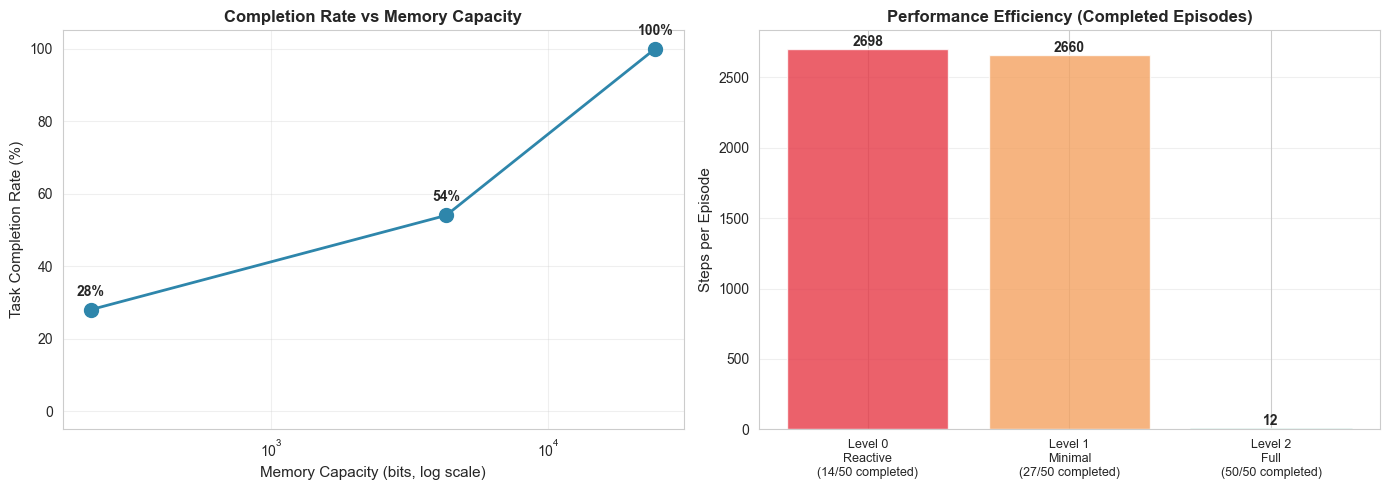


✓ Visualizations complete


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Completion Rate vs Memory
ax1 = axes[0]
memory_levels = [224, 4288, 24384]
completion_rates = [
    reactive_summary['completion_rate'] * 100,
    minimal_summary['completion_rate'] * 100,
    full_summary['completion_rate'] * 100
]

ax1.plot(memory_levels, completion_rates, 'o-', linewidth=2, markersize=10, color='#2E86AB')
ax1.set_xlabel('Memory Capacity (bits, log scale)', fontsize=11)
ax1.set_ylabel('Task Completion Rate (%)', fontsize=11)
ax1.set_title('Completion Rate vs Memory Capacity', fontsize=12, fontweight='bold')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-5, 105)

for mem, comp in zip(memory_levels, completion_rates):
    ax1.annotate(f'{comp:.0f}%', (mem, comp), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

# Plot 2: Steps per Episode (only for COMPLETED episodes)
ax2 = axes[1]

# Use completed steps where available, otherwise average
steps_data = [
    reactive_summary['avg_steps_completed'] if reactive_summary['avg_steps_completed'] else reactive_summary['avg_steps'],
    minimal_summary['avg_steps_completed'] if minimal_summary['avg_steps_completed'] else minimal_summary['avg_steps'],
    full_summary['avg_steps']
]

labels = [
    f"Level 0\nReactive\n({reactive_summary['completed']}/{reactive_summary['total_trials']} completed)",
    f"Level 1\nMinimal\n({minimal_summary['completed']}/{minimal_summary['total_trials']} completed)",
    f"Level 2\nFull\n({full_summary['completed']}/{full_summary['total_trials']} completed)"
]

colors = ['#E63946', '#F4A261', '#06A77D']
bars = ax2.bar(range(3), steps_data, color=colors, alpha=0.8)
ax2.set_xticks(range(3))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Steps per Episode', fontsize=11)
ax2.set_title('Performance Efficiency (Completed Episodes)', fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

for bar, steps in zip(bars, steps_data):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{steps:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete")

## Interpretation

In [24]:
print("="*70)
print("INTERPRETATION")
print("="*70)

# Check if Level 1 is actually better
if minimal_summary['completion_rate'] > reactive_summary['completion_rate']:
    print(f"\n✓ MEMORY HIERARCHY WORKS:")
    print(f"  Level 0 → 1: {4288/224:.0f}x memory → "
          f"{(minimal_summary['completion_rate']/reactive_summary['completion_rate'] if reactive_summary['completion_rate'] > 0 else float('inf')):.1f}x completion")
    
    if minimal_summary['avg_steps_completed'] and full_summary['avg_steps']:
        print(f"  Level 1 → 2: {24384/4288:.1f}x memory → "
              f"{minimal_summary['avg_steps_completed']/full_summary['avg_steps']:.1f}x efficiency per trip")
        print(f"              (but requires {training_steps:,} training steps)")
else:
    print(f"\n⚠️  UNEXPECTED: Level 1 NOT better than Level 0!")
    print(f"\nPossible causes:")
    print(f"  • Novelty penalty too strong → avoiding useful areas")
    print(f"  • Visit tracking causing loops instead of preventing them")
    print(f"  • Need to tune parameters")
    
    print(f"\nDiagnostics:")
    print(f"  Level 0 stuck: {reactive_summary['stuck_in_loop']}/{reactive_summary['total_trials']}")
    print(f"  Level 1 stuck: {minimal_summary['stuck_in_loop']}/{minimal_summary['total_trials']}")
    
    if minimal_summary['stuck_in_loop'] > reactive_summary['stuck_in_loop']:
        print(f"\n  → Level 1 gets stuck MORE often - novelty penalty backfiring!")

print("\n" + "="*70)

INTERPRETATION

✓ MEMORY HIERARCHY WORKS:
  Level 0 → 1: 19x memory → 1.9x completion
  Level 1 → 2: 5.7x memory → 221.6x efficiency per trip
              (but requires 29,314 training steps)

